In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

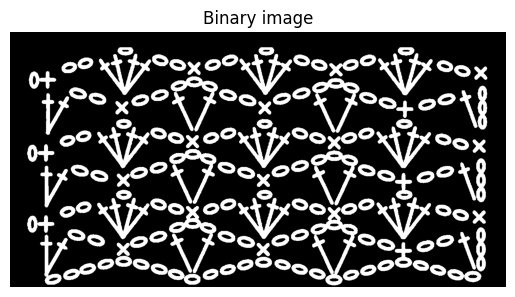

In [10]:
IMAGE_PATH = "data/raw/easy/4.png"

img = cv2.imread(IMAGE_PATH, 0)

# Binary (symbols = white)
_, thresh = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Binary image")
plt.axis("off")
plt.show()

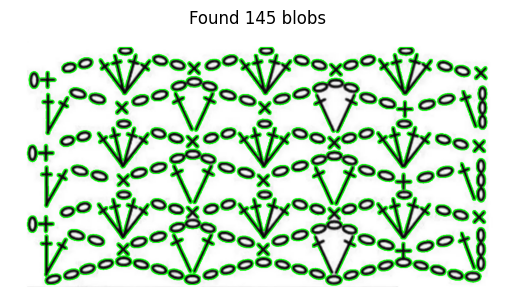

In [11]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

debug = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(debug, contours, -1, (0,255,0), 2)

plt.imshow(debug)
plt.title(f"Found {len(contours)} blobs")
plt.axis("off")
plt.show()

In [12]:
def find_concave_points(contour, depth_thresh=1000):
    hull = cv2.convexHull(contour, returnPoints=False)
    defects = cv2.convexityDefects(contour, hull)

    points = []

    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, d = defects[i, 0]
            far = tuple(contour[f][0])

            if d > depth_thresh:
                points.append(far)

    return points

In [13]:
def split_contour(mask, contour, depth_thresh=1000):
    concave_pts = find_concave_points(contour, depth_thresh)

    # draw filled contour
    local_mask = np.zeros_like(mask)
    cv2.drawContours(local_mask, [contour], -1, 255, -1)

    # cut at concave points
    for p in concave_pts:
        cv2.circle(local_mask, p, 4, 0, -1)

    # split
    num_labels, labels = cv2.connectedComponents(local_mask)

    pieces = []
    for label in range(1, num_labels):
        piece = np.zeros_like(mask)
        piece[labels == label] = 255
        pieces.append(piece)

    return pieces, concave_pts

In [21]:
all_symbols = []
debug_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for cnt in contours:
    # skip tiny noise
    x, y, w, h = cv2.boundingRect(cnt)
    if w < 15 or h < 15:
        continue

    pieces, concave_pts = split_contour(thresh, cnt, depth_thresh=1000)

    # draw concave points
    for p in concave_pts:
        cv2.circle(debug_img, p, 5, (0,0,255), -1)

    for piece in pieces:
        x, y, w, h = cv2.boundingRect(piece)
        symbol = img[y:y+h, x:x+w]

        if w > 10 and h > 10:
            all_symbols.append(symbol)

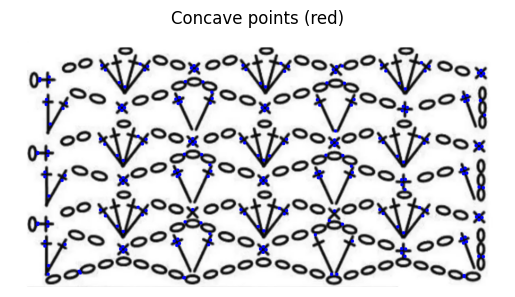

In [22]:
plt.imshow(debug_img)
plt.title("Concave points (red)")
plt.axis("off")
plt.show()

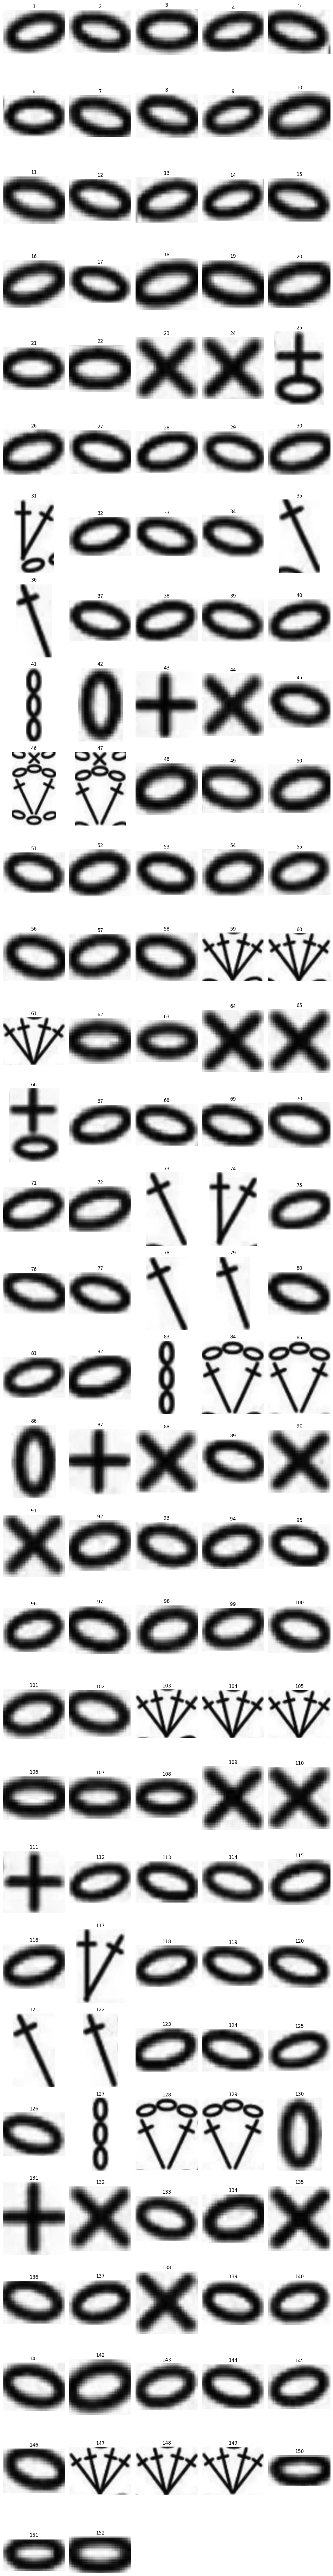

In [16]:
import math

def show_symbols(symbols, cols=5):
    rows = math.ceil(len(symbols) / cols)
    plt.figure(figsize=(12, 3 * rows))

    for i, sym in enumerate(symbols):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(sym, cmap='gray')
        plt.title(f"{i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_symbols(all_symbols)

/var/folders/b5/4hk8xrkx3x50b85sdqdmy76w0000gn/T/ipykernel_43794/1604894316.py:24: RuntimeWarning: When min_distance < 1, peak_local_max acts as finding image > max(threshold_abs, threshold_rel * max(image)).
  coordinates = peak_local_max(


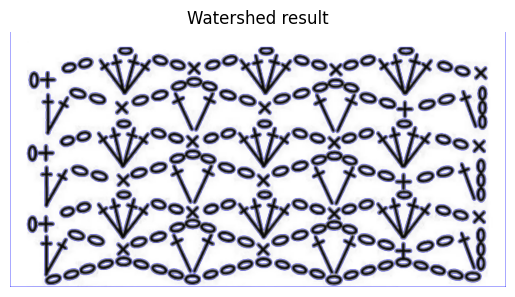

KeyboardInterrupt: 

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.feature import peak_local_max

# Load image
img = cv2.imread("data/raw/easy/4.png", 0)

# Binary (symbols = white)
_, thresh = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY_INV)

# Clean noise
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Distance transform
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Normalize (optional but helps)
dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

# --- KEY STEP: find local maxima ---
coordinates = peak_local_max(
    dist_norm,
    min_distance=0,   # <-- TUNE THIS
    labels=opening
)

# Create markers
markers = np.zeros(dist.shape, dtype=np.int32)

for i, coord in enumerate(coordinates):
    markers[coord[0], coord[1]] = i + 1

# Watershed expects background = 1
markers = markers + 1
markers[opening == 0] = 0

# Apply watershed
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)

# Visualize boundaries
img_color[markers == -1] = [0, 0, 255]

plt.imshow(img_color)
plt.title("Watershed result")
plt.axis("off")
plt.show()

# --- Extract symbols ---
symbols = []
for label in range(2, markers.max() + 1):
    mask = np.zeros_like(img, dtype=np.uint8)
    mask[markers == label] = 255

    x, y, w, h = cv2.boundingRect(mask)
    if w > 10 and h > 10:
        symbols.append(img[y:y+h, x:x+w])

# Show results
cols = 5
rows = int(np.ceil(len(symbols) / cols))

plt.figure(figsize=(12, 3 * rows))

for i, sym in enumerate(symbols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(sym, cmap='gray')
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Extracted symbols:", len(symbols))